In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load dataset
df = pd.read_csv("ecommerce_sales_dataset.csv")

In [9]:
#basic exploration

print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (20000, 19)

Columns: Index(['OrderID', 'CustomerID', 'OrderDate', 'ProductName', 'Category',
       'SubCategory', 'Price', 'Quantity', 'DiscountPercent', 'TotalAmount',
       'PaymentMethod', 'OrderStatus', 'DeliveryTimeDays', 'CustomerLocation',
       'Rating', 'Revenue', 'Year', 'Month', 'Day'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   OrderID           20000 non-null  object        
 1   CustomerID        20000 non-null  object        
 2   OrderDate         20000 non-null  datetime64[ns]
 3   ProductName       20000 non-null  object        
 4   Category          20000 non-null  object        
 5   SubCategory       20000 non-null  object        
 6   Price             20000 non-null  float64       
 7   Quantity          20000 non-null  int64         
 8   Discoun

# Data Cleaning

In [5]:
df = df.drop_duplicates()

# Handle missing values
# Numerical columns → median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns → mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Feature Engineering

In [19]:
# Create Revenue column
df['Revenue'] = df['Price'] * df['Quantity']

# Extract date features
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['Day'] = df['OrderDate'].dt.day

df.head()

,OrderID,CustomerID,OrderDate,ProductName,Category,SubCategory,Price,Quantity,DiscountPercent,TotalAmount,PaymentMethod,OrderStatus,DeliveryTimeDays,CustomerLocation,Rating,Revenue,Year,Month,Day
0,ORD00000001,CUS000001,2024-03-09,Cricket Bat,Sports,Equipment,1202.64,3,0,3607.92,Debit Card,Returned,4.0,Chicago,2.0,3607.92,2024,3,9
1,ORD00000002,CUS000002,2025-06-26,Bluetooth Headphones,Electronics,Audio,909.62,8,10,6549.26,UPI,Cancelled,1.0,Melbourne,2.0,7276.96,2025,6,26
2,ORD00000003,CUS000003,2025-12-21,Wireless Mouse,Electronics,Accessories,1104.83,8,20,7070.91,Net Banking,Returned,1.0,Denver,3.0,8838.64,2025,12,21
3,ORD00000004,CUS000004,2025-11-14,Sunglasses,Fashion,Accessories,188.34,2,15,320.18,Debit Card,Cancelled,1.0,Pune,3.0,376.68,2025,11,14
4,ORD00000005,CUS000005,2024-05-22,Denim Jeans,Fashion,Apparel,1069.15,3,30,2245.22,UPI,Returned,2.0,San Diego,2.0,3207.45,2024,5,22


# KPI Calculation

In [7]:

total_revenue = df['Revenue'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = total_revenue / total_orders

print("\n===== KPIs =====")
print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)


===== KPIs =====
Total Revenue: 82411783.49000001
Total Orders: 20000
Average Order Value: 4120.589174500001


# Exploratory Data Analysis (EDA)


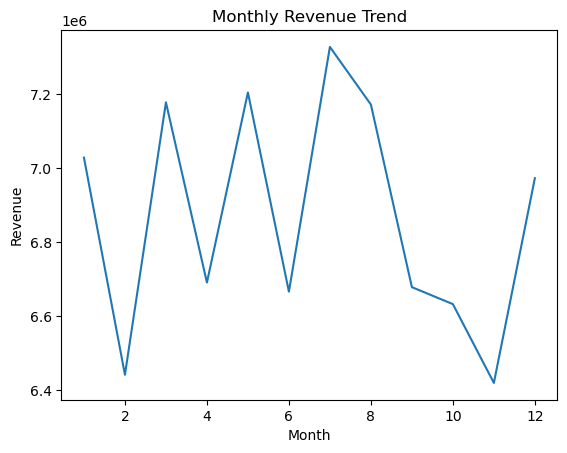

In [10]:
# Revenue by Month
monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

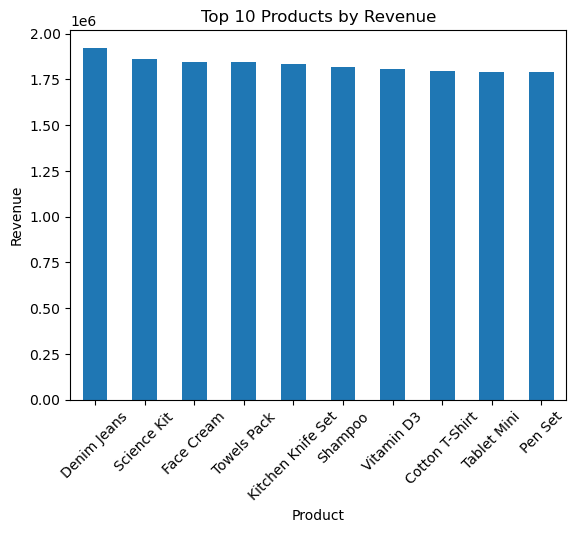

In [11]:
# Top 10 Products by Revenue
top_products = df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

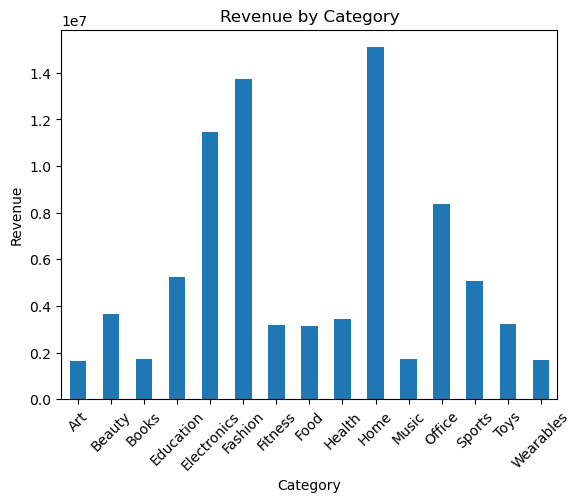

In [12]:
# Sales by Category
category_sales = df.groupby('Category')['Revenue'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Correlation Analysis


Correlation Matrix:
                     Price  Quantity  DiscountPercent  TotalAmount  \
Price             1.000000 -0.002414        -0.000742     0.678040   
Quantity         -0.002414  1.000000        -0.007996     0.616372   
DiscountPercent  -0.000742 -0.007996         1.000000    -0.138242   
TotalAmount       0.678040  0.616372        -0.138242     1.000000   
DeliveryTimeDays  0.008649  0.002832        -0.000916     0.014329   
Rating           -0.004577  0.017997         0.004664     0.005480   
Revenue           0.688898  0.626306         0.000117     0.983727   
Year             -0.002219 -0.002576        -0.000367    -0.002477   
Month             0.004852 -0.013245         0.000649    -0.005453   
Day              -0.000173  0.011514        -0.002685     0.007350   

                  DeliveryTimeDays    Rating   Revenue      Year     Month  \
Price                     0.008649 -0.004577  0.688898 -0.002219  0.004852   
Quantity                  0.002832  0.017997  0.6263

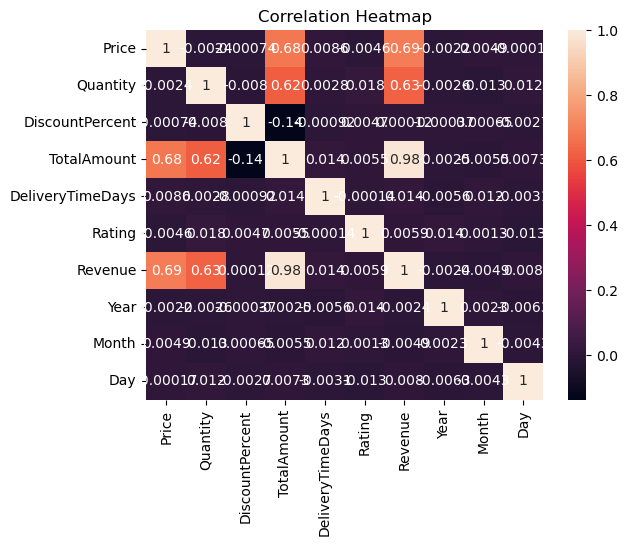

In [13]:
corr = df.select_dtypes(include=np.number).corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()


# Distribution Analysis

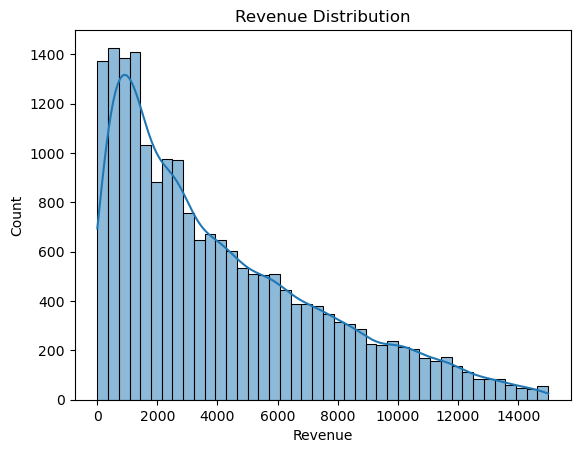

In [15]:
plt.figure()
sns.histplot(df['Revenue'], kde=True)
plt.title("Revenue Distribution")
plt.show()


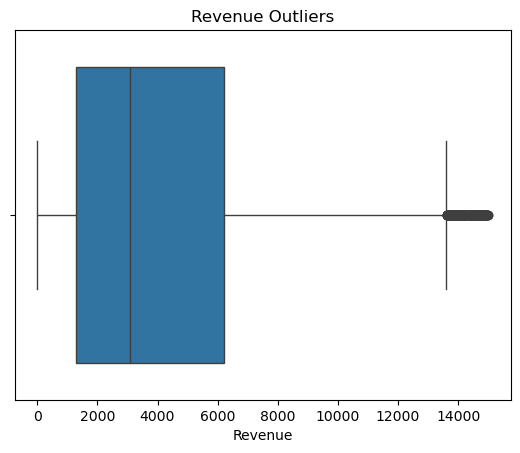

In [16]:
plt.figure()
sns.boxplot(x=df['Revenue'])
plt.title("Revenue Outliers")
plt.show()

# Customer Behavior Analysis

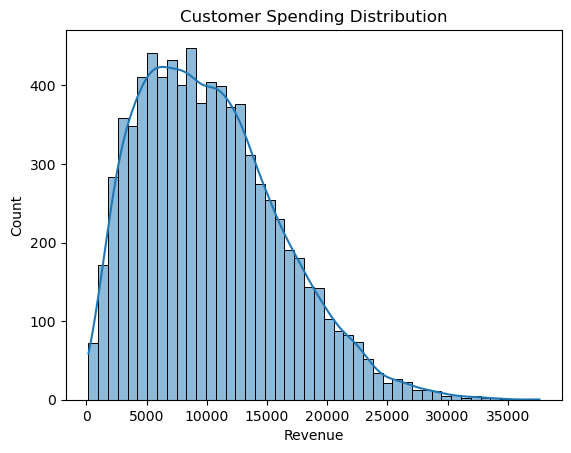

In [17]:
customer_spending = df.groupby('CustomerID')['Revenue'].sum()

plt.figure()
sns.histplot(customer_spending, kde=True)
plt.title("Customer Spending Distribution")
plt.show()

# Saved Cleaned Data

In [18]:
df.to_csv("cleaned_ecommerce_data.csv", index=False)

print("\n✅ Analysis Completed Successfully!")


✅ Analysis Completed Successfully!
